# Trabajo 3: De la demanda microsimulada a la propuesta de localización de un servicio

## 1. Introducción

El presente informe tiene como propósito fundamental diseñar un modelo de evaluación espacial para proyectar la localización óptima de una nueva sucursal para la **Botillería 7LIRAS**. El objetivo estratégico de esta iniciativa es la expansión física del negocio para capturar nueva demanda e incrementar la rentabilidad, focalizando el análisis en el sector sur-poniente de la Región Metropolitana (comprendiendo las comunas de Maipú, Cerrillos, Estación Central y Pudahuel). 

### 1.1 Selección del Servicio y Justificación Metodológica
Para el desarrollo del modelo predictivo, se ha seleccionado el servicio de comercialización de **Bebidas Alcohólicas**. Esta elección se fundamenta en tres pilares exigidos para el análisis de demanda espacial:

* **(a) Relevancia Territorial:** Conocer la distribución espacial del presupuesto destinado a alcohol crítico para decidir la ubicación exacta de un nuevo local comercial. Identificar los "puntos calientes" de consumo permite justificar empíricamente la inversión en una nueva botillería física, asegurando que se instale en un barrio con alta rentabilidad potencial.
* **(b) Geolocalización de la Oferta:** El mercado de abastecimiento de licores (botillerías, tiendas de conveniencia y cadenas de supermercados) presenta una alta fijación estática. Sus locales físicos son entidades comerciales claramente geolocalizables en el entorno urbano, lo que permitirá en etapas posteriores contrastar la demanda microsimulada con la competencia existente para encontrar nichos desatendidos.
* **(c) Representatividad en la EPF (Categoría CCIF):** Para garantizar la solidez estadística, se utilizó la Clasificación del Consumo Individual por Finalidades (CCIF) de la Encuesta de Presupuestos Familiares (EPF). Se consolidó el gasto bajo la categoría macro **`02.1` ("Bebidas Alcohólicas")**, agrupando ítems de alta rotación como cervezas, vinos y licores. Esta agrupación asegura un tamaño muestral robusto (una cantidad estadísticamente significativa de individuos que reportan gasto positivo) para entrenar con precisión el modelo econométrico de dos partes.

### 1.2 Variables Utilizadas en el Modelo

Para la construcción del modelo de dos partes y la posterior microsimulación espacial, se extrajeron y homologaron diversas variables provenientes de la Encuesta de Presupuestos Familiares (EPF), la Encuesta CASEN y el CENSO. Estas se agrupan en las siguientes categorías:

**A. Variables Dependientes (Objetivo):**
Extraídas y calculadas a partir de la base de gastos de la EPF (filtrando el código CCIF `02.1`).
* **`incurre_gasto`:** Variable dicotómica (binaria) que asume el valor 1 si el individuo reportó algún gasto mayor a cero en bebidas alcohólicas, y 0 en caso contrario. Es la variable dependiente del modelo Logit.
* **`gasto_bien` / `log_gasto_bien`:** Variable continua que representa el monto total en pesos (CLP) gastado por el individuo. Para su uso en el modelo de Mínimos Cuadrados Ordinarios (OLS), se aplicó una transformación logarítmica para normalizar la distribución de los datos y reducir el impacto de valores extremos.

**B. Variables Independientes (Explicativas y Sociodemográficas):**
Utilizadas como predictores en los modelos econométricos, homologadas entre la EPF y la CASEN.
* **`sexo_lbl`:** Variable categórica que identifica el sexo del individuo (Hombre / Mujer).
* **`edad` / `rango_edad`:** Variable continua de la edad del encuestado, la cual fue discretizada en cuatro categorías para capturar efectos no lineales en el consumo: *menores_edad* (0-17 años), *jovenes_adultos* (18-44 años), *Adultos* (45-64 años) y *Adultos Mayores* (65 o más).
* **`edue` (EPF) / `esc` (CASEN):** Años de escolaridad formal. Se recodificó en la variable `grupo_escolaridad` con cuatro niveles: *Escolar*, *Técnico*, *Universitaria* y *Postgrado*. En la base CASEN, los valores nulos fueron imputados mediante una regresión lineal simple.
* **`ing_pc`:** Ingreso per cápita del hogar, calculado como el ingreso disponible del hogar dividido por el número de integrantes.

**C. Variables de Expansión Espacial y Microsimulación (IPF):**
Variables de control utilizadas para cruzar los individuos de la CASEN con las zonas censales.
* **`comuna` / `CUT`:** Código Único Territorial utilizado para filtrar estrictamente el área de interés comercial (Maipú, Cerrillos, Estación Central y Pudahuel).
* **`OBJECTID`:** Identificador único de cada manzana o zona censal.
* **`tenencia_cat`:** Variable categórica construida en la CASEN y homologada con el Censo que define el régimen de propiedad de la vivienda (propia pagada, propia pagándose, arrendada, cedida, etc.), actuando como *constraint* fundamental en el algoritmo de clonación poblacional (IPF).

### 1.3 Cálculo y Transformación de Variables

Para asegurar la robustez de las estimaciones, las variables base extraídas de las encuestas oficiales fueron sometidas a procesos de cálculo y recodificación:

* **Ingreso per cápita (`ing_pc`):** Se calculó dividiendo el ingreso disponible del hogar (`ing_disp_hog_hd_ai`) por el número total de integrantes del mismo (`npersonas`).
* **Identificador Único (`id_persona`):** Se generó concatenando el folio del hogar con el número de línea de cada integrante, permitiendo cruzar la base sociodemográfica con los registros de gastos individuales.
* **Agrupación de Gasto (`gasto_bien`):** Se sumaron todos los montos reportados en la base de cantidades de la EPF cuyo código CCIF comenzara con "02.1" (Bebidas Alcohólicas), agrupándolos a nivel de persona.
* **Variable de Decisión (`incurre_gasto`):** Se construyó evaluando la variable `gasto_bien`. Si el monto era mayor a cero, se le asignó el valor 1 (incurre en gasto); de lo contrario, se le asignó 0.
* **Normalización del Monto (`log_gasto_bien`):** Para el modelo de regresión lineal, el gasto continuo se transformó aplicando el logaritmo natural al monto más uno (`ln(gasto + 1)`), corrigiendo así el sesgo de la distribución original.
* **Segmentación Etaria (`rango_edad`):** Se recodificó la edad en cuatro segmentos estratégicos de consumo: *Menores de edad* (0 a 17 años), *Jóvenes-Adultos* (18 a 44 años), *Adultos* (45 a 64 años) y *Adultos Mayores* (65 años o más).
* **Demanda Individual Proyectada (`demanda_ind`):** Es el resultado matemático final a nivel de individuo, obtenido al multiplicar la probabilidad de compra predicha (Logit) por el gasto potencial estimado (OLS, transformado de vuelta a pesos chilenos).

### 1.4 Objetivo General

Estimar y espacializar la demanda potencial de bebidas alcohólicas a nivel de zona censal, mediante la integración metodológica de modelos econométricos y técnicas de microsimulación, con el fin de fundamentar de manera empírica la selección de la ubicación más rentable para la apertura de una nueva sucursal física de la **Botillería 7LIRAS** en las comunas del sector sur-poniente de la capital (Maipú, Cerrillos, Estación Central y Pudahuel).

## 2. Desarrollo

### 2.1 Librería

In [232]:
# 1. LIBRERÍA

!pip install osmnx
import numpy as np
import pandas as pd
import geopandas as gpd
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import statsmodels.formula.api as smf
import contextlib
import io
import warnings
import osmnx as ox
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, roc_curve
from ipfn import ipfn
from shapely.geometry import Point


### 2.2 Conexión Base de Datos

In [1]:
# 1. RUTA DE LOS ARCHIVOS

RUTA_CENSO_ZONAL = "../Parquet/Cartografía_censo2024_R13_Zonal.parquet"
RUTA_CASEN = "../Parquet/casen_rm.rds"
RUTA_EPF_PERSONAS = "../base-personas-ix-epf-stata.dta"
RUTA_EPF_CANTIDADES = "../base-cantidades-ix-epf-stata.dta"

SEED=123

### 2.3 Pre-procesamiento de datos y creación variable objetivo

 La primera fase metodológica consistió en la limpieza y estructuración de la Encuesta de Presupuestos Familiares (EPF). Para asegurar la pertinencia territorial del análisis, la muestra fue filtrada exclusivamente para la Macrozona 2 (Gran Santiago). Asimismo, se eliminaron aquellos registros sociodemográficos con respuestas inválidas o nulas (codificadas originalmente como -99, -88 o -77) en las variables de edad, escolaridad e ingresos. A partir de esta base depurada, se estandarizó la variable económica calculando el ingreso per cápita del hogar (`ing_pc`).

**Definición del Servicio y Justificación Comercial:**
El objetivo central de este estudio es diagnosticar el territorio para proyectar la localización óptima de una nueva sucursal para la **Botillería 7LIRAS**. El ítem seleccionado para estimar el gasto potencial corresponde a la categoría de **Bebidas Alcohólicas**. 

Para capturar la demanda de manera realista, se recurrió al diccionario de Clasificación del Consumo Individual por Finalidades (CCIF). En lugar de restringir el análisis a un solo producto específico, se procedió a agrupar todos los registros de la base de gastos que comenzaran con el código macro `02.1` ("Bebidas Alcohólicas"). Esta decisión estratégica permite consolidar el gasto reportado en cervezas, vinos, destilados y licores (subcategorías 02.1.1, 02.1.2 y 02.1.3), reflejando con exactitud el comportamiento de compra frente al catálogo multiproducto de una botillería real.

**Construcción de las Variables a Modelar:**
Una vez consolidado el gasto total en alcohol por identificador único de persona (`id_persona`), se generaron las dos variables dependientes que alimentarán el modelo estadístico en las siguientes etapas:
1.  **Variable de Decisión (`incurre_gasto`):** Un indicador binario (1 o 0) que señala si el individuo realizó o no compras en la categoría, el cual será utilizado en la regresión logística para estimar la probabilidad de consumo.
2.  **Variable de Monto (`gasto_bien`):** La sumatoria monetaria continua de lo gastado por la persona, la cual será utilizada, tras una normalización logarítmica, para estimar el ticket promedio esperado mediante Mínimos Cuadrados Ordinarios (OLS).

In [234]:
# 1. CARGA Y LIMPIEZA INICIAL DE LA EPF
personas = pd.read_stata(RUTA_EPF_PERSONAS, convert_categoricals=False)
cantidades = pd.read_stata(
    RUTA_EPF_CANTIDADES, convert_categoricals=False,
    columns=["folio", "n_linea", "ccif", "macrozona", "gasto"],
)

In [235]:
# 2. FILTRAMOS PARA QUEDARNOS SOLO CON EL GRAN SANTIAGO (MACROZONA 2) Y DATOS VÁLIDOS
valores_invalidos = [-99, -88, -77]
epf = personas[
    (personas["macrozona"] == 2)
    & (~personas["edad"].isin(valores_invalidos))
    & (~personas["edue"].isin(valores_invalidos))
    & (personas["ing_disp_hog_hd_ai"] >= 0)
].copy()

In [236]:
# 3. CREAMOS EL INGRESO PER CÁPITA Y EL IDENTIFICADOR ÚNICO
epf["ing_pc"] = epf["ing_disp_hog_hd_ai"] / epf["npersonas"]
epf["id_persona"] = epf["folio"].astype(str) + "_" + epf["n_linea"].astype("Int64").astype(str)
cantidades["id_persona"] = cantidades["folio"].astype(str) + "_" + cantidades["n_linea"].astype("Int64").astype(str)

In [237]:
# 4. FILTRO COMERCIAL 7LIRAS: TODO EL GASTO EN BEBIDAS ALCOHÓLICAS
gasto_alcohol = cantidades[
    (cantidades["ccif"].astype(str).str.startswith("02.1")) & 
    (cantidades["macrozona"] == 2)
]

In [238]:
# 5. SUMAMOS EL GASTO TOTAL EN ALCOHOL POR CADA PERSONA
gasto_por_persona = gasto_alcohol.groupby("id_persona")["gasto"].sum().reset_index()
gasto_por_persona.columns = ["id_persona", "gasto_bien"]

In [239]:
# 6. VARIABLE OBJETIVO: UNIMOS Y DEFINIMOS QUIÉN COMPRA Y QUIÉN NO
epf = epf.merge(gasto_por_persona, on="id_persona", how="left")
epf["gasto_bien"] = epf["gasto_bien"].fillna(0)
epf["incurre_gasto"] = (epf["gasto_bien"] > 0).astype(int)

In [240]:
# 7. RESULTADOS   
print(f"Personas totales en la muestra válida del Gran Santiago: {len(epf)}")
print(f"Personas que SÍ gastan en alcohol: {epf['incurre_gasto'].sum()} "
      f"({100 * epf['incurre_gasto'].mean():.1f}%)")

Personas totales en la muestra válida del Gran Santiago: 17340
Personas que SÍ gastan en alcohol: 2530 (14.6%)


### 2.4 EDA

En esta etapa, utilizaremos los datos recién depurados para trazar el perfil exacto del cliente que invierte en bebidas alcohólicas dentro del Gran Santiago. Entender la demografía detrás del consumo (si son los jóvenes o los adultos quienes lideran la demanda, si existe una brecha entre hombres y mujeres, y cómo influye el nivel educativo en el presupuesto) nos entregará el respaldo empírico necesario para tomar decisiones de negocio sólidas. 

En definitiva, estos hallazgos serán la brújula que nos permitirá justificar estratégicamente dónde instalaremos la nueva sucursal de **7LIRAS** y hacia quiénes debemos enfocar nuestras futuras campañas de marketing.

In [241]:
# 1. RECODIFICACIÓN DE VARIABLES (PARA QUE COINCIDAN CON LA CASEN)

epf["grupo_escolaridad"] = pd.cut(
    epf["edue"], bins=[-np.inf, 12, 14, 16, np.inf],
    labels=["Escolar", "Tecnico", "Universitaria", "Postgrado"],
)
epf["rango_edad"] = pd.cut(
    epf["edad"], bins=[-1, 17, 44, 64, np.inf],  
    labels=["menores_edad", "jovenes_adultos", "adultos", "adultos_mayores"],
)
epf["sexo_lbl"] = epf["sexo"].map({1: "Hombre", 2: "Mujer"})

In [242]:
# 2. REVISIÓN RÁPIDA DE PROMEDIOS ENTRE LOS QUE GASTAN Y NO GASTAN
print(epf.groupby("incurre_gasto")[["edad", "ing_pc"]].mean().round(0))

               edad    ing_pc
incurre_gasto                
0              36.0  583105.0
1              45.0  906327.0


#### 2.4.1 Gráficos de monto de gasto

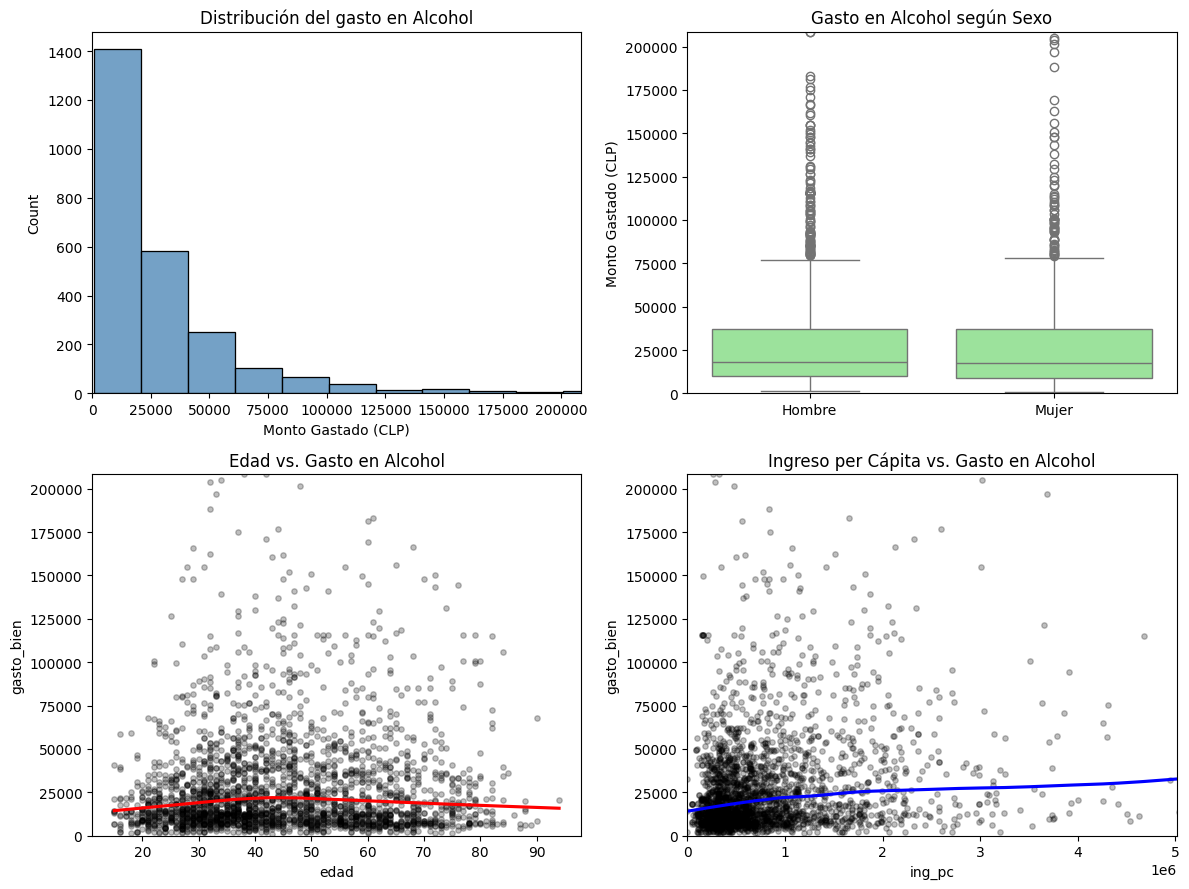

In [243]:
# 1. GRÁFICOS DE MONTO DE GASTO (SOLO PARA LOS QUE SÍ COMPRARON ALCOHOL)
spenders = epf[epf["gasto_bien"] > 0]
tope_grafico = spenders["gasto_bien"].quantile(0.99)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 2. DISTRIBUCIÓN DEL GASTO
sns.histplot(spenders["gasto_bien"], bins=30, color="steelblue", ax=axes[0, 0])
axes[0, 0].set_xlim(0, tope_grafico)
axes[0, 0].set_title("Distribución del gasto en Alcohol")
axes[0, 0].set_xlabel("Monto Gastado (CLP)")

# 3. GASTO SEGÚN SEXO
sns.boxplot(data=spenders, x="sexo_lbl", y="gasto_bien", ax=axes[0, 1], color="lightgreen")
axes[0, 1].set_ylim(0, tope_grafico)
axes[0, 1].set_title("Gasto en Alcohol según Sexo")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Monto Gastado (CLP)")

# 4. EDAD VS GASTO
sns.regplot(
    data=spenders, x="edad", y="gasto_bien", ax=axes[1, 0],
    scatter_kws={"alpha": 0.25, "s": 15, "color": "black"},
    lowess=True, line_kws={"color": "red"},
)
axes[1, 0].set_ylim(0, tope_grafico)
axes[1, 0].set_title("Edad vs. Gasto en Alcohol")

# 5. INGRESO VS GASTO
sns.regplot(
    data=spenders, x="ing_pc", y="gasto_bien", ax=axes[1, 1],
    scatter_kws={"alpha": 0.25, "s": 15, "color": "black"},
    lowess=True, line_kws={"color": "blue"},
)
axes[1, 1].set_ylim(0, tope_grafico)
axes[1, 1].set_xlim(0, spenders["ing_pc"].quantile(0.99))
axes[1, 1].set_title("Ingreso per Cápita vs. Gasto en Alcohol")

plt.tight_layout()
plt.show()

#### 2.4.2 Análisis Gráficos de monto de gasto

A partir de la muestra de individuos que reportaron compras en bebidas alcohólicas, se observan los siguientes comportamientos en cuanto a los montos desembolsados:

* **Distribución del Gasto:** El consumo es marcadamente asimétrico. La gran mayoría de los clientes gasta montos bajos (concentrándose bajo los \$25.000), mientras que solo una pequeña minoría realiza compras de alto valor.
* **Gasto según Sexo:** No existen diferencias significativas en los montos desembolsados por hombres y mujeres. En ambos grupos, la mediana de gasto se sitúa de forma muy similar en torno a los \$20.000.
* **Edad vs. Gasto:** El ticket promedio sigue una curva de ciclo de vida. El monto gastado crece gradualmente en la juventud, alcanza su punto máximo entre los 40 y 50 años, y comienza a descender en la tercera edad.
* **Ingreso vs. Gasto:** Se evidencia una relación lineal positiva. Tal como indica la línea de tendencia, a mayor ingreso per cápita del individuo, mayor es el presupuesto que destina a la categoría de bebidas alcohólicas.

#### 2.4.3 Gráficos Probabilidad de compra

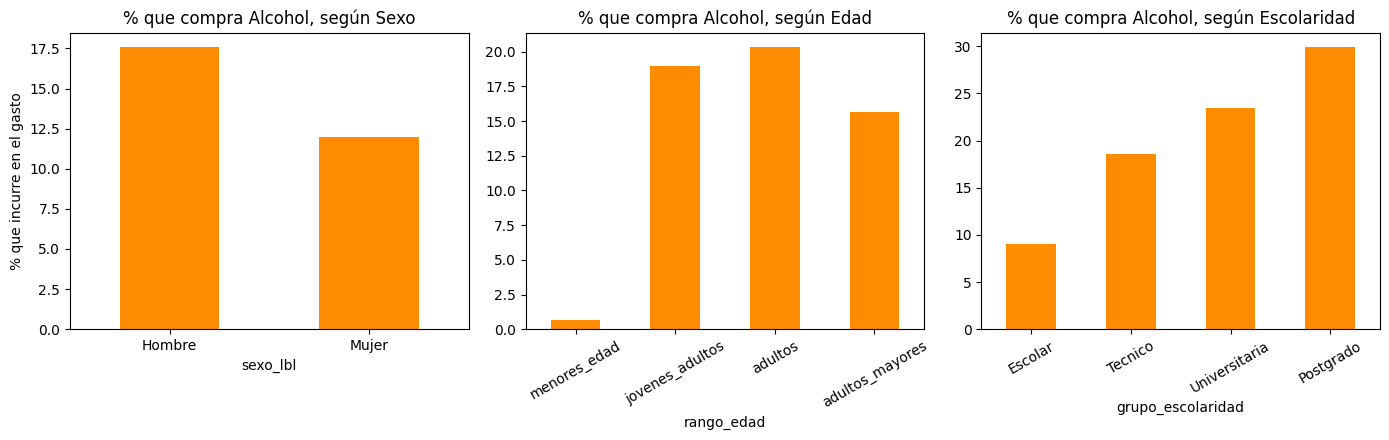

In [244]:
# GRÁFICOS DE PROBABILIDAD DE COMPRA 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

epf.groupby("sexo_lbl")["incurre_gasto"].mean().mul(100).plot.bar(ax=axes[0], color="darkorange")
axes[0].set_title("% que compra Alcohol, según Sexo")
axes[0].set_ylabel("% que incurre en el gasto")
axes[0].tick_params(axis="x", rotation=0)

epf.groupby("rango_edad", observed=True)["incurre_gasto"].mean().mul(100).plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("% que compra Alcohol, según Edad")
axes[1].tick_params(axis="x", rotation=30)

orden_escolaridad = ["Escolar", "Tecnico", "Universitaria", "Postgrado"]
epf.groupby("grupo_escolaridad", observed=True)["incurre_gasto"].mean().reindex(orden_escolaridad).mul(100).plot.bar(ax=axes[2], color="darkorange")
axes[2].set_title("% que compra Alcohol, según Escolaridad")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

#### 2.4.4 Análisis de gráficos Probabilidad de compra

Al analizar la decisión de compra (es decir, qué porcentaje de cada grupo efectivamente gasta dinero en bebidas alcohólicas), se identifican los siguientes patrones:

* **Según Sexo:** Los hombres presentan una mayor propensión a incurrir en este gasto, superando el 17.5%, mientras que la participación de las mujeres se sitúa cerca del 12%.
* **Según Edad:** La segmentación confirma que el consumo reportado en *Menores de Edad* es prácticamente nulo, validando la precisión del modelo. La mayor probabilidad de compra se concentra sólidamente en los *Adultos* (\~20%) y los *Jóvenes-Adultos* (\~19%), descendiendo a un 15.5% en los *Adultos Mayores*.
* **Según Escolaridad:** Se observa una relación directa y fuertemente escalonada. A mayor nivel educativo, aumenta la proporción de personas que compran alcohol: comienza en un 9% para la educación *Escolar* y alcanza su punto máximo (30%) en el grupo con *Postgrado*.

### 2.5 Modelo LOGIT y Regresión Lineal

In [245]:
# 1. REPARACIÓN DE DATOS PARA LOS MODELOS
# Eliminamos registros nulos en nuestras variables clave
modelo_data = epf.dropna(subset=["edad", "grupo_escolaridad", "sexo_lbl", "ing_pc"]).copy()

#### 2.5.1 Modelo LOGIT

RESULTADOS DEL MODELO LOGIT (PROBABILIDAD)
                           Logit Regression Results                           
Dep. Variable:          incurre_gasto   No. Observations:                17340
Model:                          Logit   Df Residuals:                    17333
Method:                           MLE   Df Model:                            6
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                 0.09489
Time:                        01:08:34   Log-Likelihood:                -6521.8
converged:                       True   LL-Null:                       -7205.5
Covariance Type:            nonrobust   LLR p-value:                2.778e-292
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                -2.9618      0.063    -47.077      0.000      -3.085      -2.838
C(sexo_

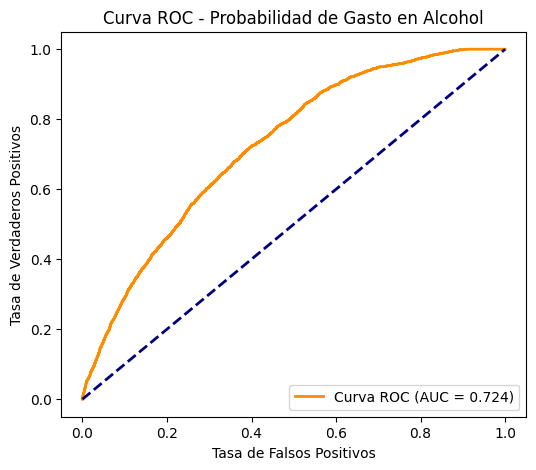

In [246]:
# PARTE 1: 
# 1. MODELO LOGIT (PROBABILIDAD DE COMPRA)
modelo_logit = smf.logit(
    "incurre_gasto ~ C(sexo_lbl) + edad + C(grupo_escolaridad) + ing_pc",
    data=modelo_data,
).fit(disp=0)

print("RESULTADOS DEL MODELO LOGIT (PROBABILIDAD)")
print(modelo_logit.summary())

# 2. CÁLCULO DEL AUC (ÁREA BAJO LA CURVA)
modelo_data["prob_predicha"] = modelo_logit.predict(modelo_data)
auc = roc_auc_score(modelo_data["incurre_gasto"], modelo_data["prob_predicha"])
print(f"\nMétrica AUC del Modelo Logit: {auc:.3f}")

# 3. GRÁFICO DE LA CURVA ROC 
fpr, tpr, thresholds = roc_curve(modelo_data["incurre_gasto"], modelo_data["prob_predicha"])
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Probabilidad de Gasto en Alcohol')
plt.legend(loc="lower right")
plt.show()

#### 2.5.2 Análisis Modelo LOGIT 

El modelo de regresión logística, entrenado con 17.340 observaciones, arroja los siguientes hallazgos estadísticos:

* **Significancia Global:** Todas las variables incluidas (sexo, escolaridad, edad e ingreso) resultaron ser altamente significativas (p-valor = 0.000), lo que valida empíricamente su capacidad para predecir el consumo.
* **Efecto del Sexo:** Ser mujer reduce de manera significativa la probabilidad de comprar bebidas alcohólicas en comparación con los hombres (coeficiente negativo de -0.54).
* **Efecto de la Escolaridad:** Se confirma una relación positiva y escalonada. Poseer estudios Técnicos, Universitarios o de Postgrado incrementa fuertemente la probabilidad de compra frente a quienes solo tienen educación Escolar (coeficientes positivos y crecientes).
* **Efecto de Edad e Ingresos:** Ambas variables continuas influyen positivamente. A mayor edad y a mayor ingreso per cápita del individuo, aumenta su probabilidad de incurrir en el gasto.
* **Precisión del Modelo:** El modelo alcanza un **AUC de 0.724**. Esto indica que tiene una capacidad de discriminación adecuada (72.4%) para distinguir correctamente entre un cliente potencial y uno que no compra.

#### 2.5.3 Análisis Gráfico Curva ROC

El gráfico de la Curva ROC visualiza el desempeño global del modelo logístico para clasificar a los consumidores:

* **Capacidad de Discriminación:** La curva naranja se eleva significativamente por encima de la línea diagonal punteada (que representa una predicción completamente al azar). Esto confirma que el modelo logró capturar patrones reales de consumo.
* **Precisión del Modelo (AUC = 0.724):** El Área Bajo la Curva indica que el algoritmo tiene un **72.4% de probabilidad** de distinguir correctamente entre una persona que efectivamente compra alcohol y una que no lo hace. En estudios de comportamiento del consumidor, este valor representa un nivel predictivo muy adecuado y estadísticamente sólido.

#### 2.5.4 Regresión lineal

In [247]:
# PARTE 2: MODELO LINEAL OLS
# 1. NOS QUEDAMOS SOLO CON LOS QUE SÍ COMPRARON ALCOHOL
tabla_gasto = epf[epf["gasto_bien"] > 0].copy()

# 2. APLICAMOS LOGARITMO PARA NORMALIZAR LA CURVA DE GASTOS
tabla_gasto["log_gasto_bien"] = np.log(tabla_gasto["gasto_bien"] + 1)

# 3. LIMPIEZA DE OUTLIERS
q_ing = tabla_gasto["ing_pc"].quantile([0.01, 0.99])
q_gasto = tabla_gasto["gasto_bien"].quantile([0.01, 0.99])
tabla_gasto = tabla_gasto[
    tabla_gasto["ing_pc"].between(q_ing.iloc[0], q_ing.iloc[1])
    & tabla_gasto["gasto_bien"].between(q_gasto.iloc[0], q_gasto.iloc[1])
]

print(f"\nPersonas válidas para entrenar el modelo de monto (OLS): {len(tabla_gasto)}")

# 4. Modelo OLS
modelo_lineal = smf.ols(
    "log_gasto_bien ~ C(grupo_escolaridad) + ing_pc + C(rango_edad) + C(sexo_lbl)",
    data=tabla_gasto,
).fit()

print("\n--- RESULTADOS DEL MODELO LINEAL (MONTO) ---")
print(modelo_lineal.summary())

def calcular_demanda(df, prob_col="prob_predicha"):
    """
    Toma la probabilidad de compra (Logit) y el gasto proyectado (OLS),
    los multiplica y devuelve la demanda potencial en pesos.
    """
    df = df.copy()
    
    df["log_gasto_pred"] = modelo_lineal.predict(df)
    df["gasto_pred"] = np.exp(df["log_gasto_pred"]) - 1

    tope = epf[epf["gasto_bien"] > 0]["gasto_bien"].quantile(0.999)
    df["gasto_pred_wins"] = df["gasto_pred"].clip(upper=tope)

    df["demanda_ind"] = df[prob_col] * df["gasto_pred_wins"]
    
    return df


Personas válidas para entrenar el modelo de monto (OLS): 2433

--- RESULTADOS DEL MODELO LINEAL (MONTO) ---
                            OLS Regression Results                            
Dep. Variable:         log_gasto_bien   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     17.95
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           2.82e-26
Time:                        01:08:40   Log-Likelihood:                -3141.3
No. Observations:                2433   AIC:                             6301.
Df Residuals:                    2424   BIC:                             6353.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.

#### 2.5.5 Análisis modelo OLS

El modelo de regresión lineal (OLS), entrenado con los 2.433 individuos que efectivamente registraron compras, presenta las siguientes conclusiones estadísticas:

* **Validez Global del Modelo:** El modelo es estadísticamente significativo en su conjunto (Prob F-statistic cercano a 0), lo que confirma que las variables elegidas explican válidamente las variaciones en el monto gastado.
* **Ingreso y Educación como Factores Clave:** El poder adquisitivo (`ing_pc`, p-valor = 0.000) y contar con educación Universitaria o Postgrado (p-valores < 0.05) son los únicos factores que incrementan de manera significativa el ticket de compra.
* **Homogeneidad Demográfica:** Una vez que el cliente decide comprar, ni su rango etario (p-valores > 0.200) ni su sexo (p-valor = 0.100) marcan una diferencia estadística en la cantidad total de dinero que gasta.
* **Poder Explicativo (R-squared):** El coeficiente de determinación es de 0.056. Esto indica que las variables sociodemográficas incluidas en el modelo logran explicar aproximadamente el 5.6% de la variabilidad en el monto exacto que gastan las personas. Aunque es un porcentaje bajo, es un resultado muy común en estudios de comportamiento individual del consumidor, ya que el gasto en alcohol depende fuertemente de factores no observables en este tipo de encuestas (como gustos personales, celebraciones puntuales, frecuencia de salidas o contexto social).

### 2.6 Microsimulación espacial

In [248]:
# 1. PREPARACIÓN DE LA CASEN
casen_raw = pyreadr.read_r(RUTA_CASEN)
casen_raw = casen_raw[list(casen_raw.keys())[0]]

vars_casen = ["estrato", "esc", "e6a", "edad", "sexo",
              "v13", "v13_propia", "v13_arrendada", "v13_cedida", "ypc"]
casen = casen_raw[vars_casen].copy()
del casen_raw

casen["comuna"] = (casen["estrato"] // 100).astype("Int64")
casen = casen.drop(columns="estrato")

# 2. IMPUTACIÓN DE ESCOLARIDAD
falta_esc = casen["esc"].isna()
modelo_esc = LinearRegression().fit(
    casen.loc[~falta_esc, ["e6a"]], casen.loc[~falta_esc, "esc"]
)
pred = modelo_esc.predict(casen.loc[falta_esc, ["e6a"]])
casen.loc[falta_esc, "esc"] = np.clip(np.round(pred), 0, 29)

casen = casen[~casen["ypc"].isna()].reset_index(drop=True)

# 3. APLICACIÓN DEL MODELO A LA CASEN
# RECODIFICAMOS LA CASEN CON LAS MISMAS REGLAS QUE USAMOS EN LA EPF
casen["grupo_escolaridad"] = pd.cut(
    casen["esc"], bins=[-np.inf, 12, 14, 16, np.inf],
    labels=["Escolar", "Tecnico", "Universitaria", "Postgrado"],
)
casen["rango_edad"] = pd.cut(
    casen["edad"], bins=[-1, 17, 44, 64, np.inf],  
    labels=["menores_edad", "jovenes_adultos", "adultos", "adultos_mayores"],
)
casen["sexo_lbl"] = casen["sexo"].map({1: "Hombre", 2: "Mujer"})
casen["ing_pc"] = casen["ypc"]

# 4. PREDECIMOS LA PROBABILIDAD Y CALCULAMOS LA DEMANDA ESPERADA
casen["prob_predicha"] = modelo_logit.predict(casen)
casen = calcular_demanda(casen)

print(f"Demanda individual promedio proyectada en la CASEN: ${casen['demanda_ind'].mean():.0f} CLP")

# 5. FILTRO TERRITORIAL 
censo_zonal = gpd.read_parquet(RUTA_CENSO_ZONAL).rename_geometry("geometry")

# DEFINIMOS NUESTRA ZONA DE ESTUDIO (7LIRAS)
comunas_estudio = ["ESTACIÓN CENTRAL", "PUDAHUEL", "CERRILLOS", "MAIPÚ"]

# FILTRAMOS LA CARTOGRAFÍA ZONAL
es_zona_estudio = censo_zonal["COMUNA"].isin(comunas_estudio)
censo_zonal = censo_zonal[es_zona_estudio].reset_index(drop=True)

# FILTRAMOS LA CARTOGRAFÍA COMUNAL (PARA LOS BORDES EN EL MAPA)
censo_comunal = gpd.read_parquet(RUTA_CENSO_ZONAL.replace("_Zonal", "_Comunal")).rename_geometry("geometry")
censo_comunal = censo_comunal[censo_comunal["COMUNA"].isin(comunas_estudio)].reset_index(drop=True)

# FILTRAMOS LAS PERSONAS DE LA CASEN PARA QUE SOLO QUEDEN LAS DE ESTAS 4 COMUNAS
comunas_cut_estudio = censo_zonal["CUT"].unique()
casen = casen[casen["comuna"].isin(comunas_cut_estudio)].reset_index(drop=True)

print(f"\nZonas censales en área de estudio (7LIRAS): {len(censo_zonal)}")
print(f"Personas CASEN en el área de estudio: {len(casen)}")

Demanda individual promedio proyectada en la CASEN: $2977 CLP

Zonas censales en área de estudio (7LIRAS): 253
Personas CASEN en el área de estudio: 5227


In [249]:
# 6. RECODIFICACIÓN CASEN 
COLS_SEXO = {"hombre": "n_hombres", "mujer": "n_mujeres"}
COLS_EDAD = {
    "edad_0_5": "n_edad_0_5", "edad_6_13": "n_edad_6_13", "edad_14_17": "n_edad_14_17",
    "edad_18_24": "n_edad_18_24", "edad_25_44": "n_edad_25_44",
    "edad_45_59": "n_edad_45_59", "edad_60_mas": "n_edad_60_mas",
}
COLS_EDUC = ["educ_nunca", "educ_primaria", "educ_secundaria", "educ_terciaria"]
COLS_TENENCIA = {
    "ten_propia_pagada": "n_tenencia_propia_pagada",
    "ten_propia_pagandose": "n_tenencia_propia_pagandose",
    "ten_arrendada_contrato": "n_tenencia_arrendada_contrato",
    "ten_arrendada_sin_contrato": "n_tenencia_arrendada_sin_contrato",
    "ten_cedida_trabajo": "n_tenencia_cedida_trabajo",
    "ten_cedida_familiar": "n_tenencia_cedida_familiar",
    "ten_otro": "n_tenencia_otro",
}

casen["sexo_cat"] = casen["sexo"].map({1: "hombre", 2: "mujer"})
casen["edad_cat"] = pd.cut(
    casen["edad"], bins=[0, 6, 14, 18, 25, 45, 60, np.inf],
    labels=list(COLS_EDAD.keys()), right=False, include_lowest=True,
).astype(str)
casen["educ_cat"] = pd.cut(
    casen["esc"], bins=[-1, 0, 8, 12, np.inf], labels=COLS_EDUC,
).astype(str)

condiciones = [
    (casen["v13"] == 1) & (casen["v13_propia"] == 1),
    (casen["v13"] == 1) & (casen["v13_propia"] == 2),
    (casen["v13"] == 2) & (casen["v13_arrendada"] == 5),
    (casen["v13"] == 2) & (casen["v13_arrendada"] == 6),
    (casen["v13"] == 3) & (casen["v13_cedida"] == 7),
    (casen["v13"] == 3) & (casen["v13_cedida"] == 8),
]
categorias_tenencia = [
    "ten_propia_pagada", "ten_propia_pagandose",
    "ten_arrendada_contrato", "ten_arrendada_sin_contrato",
    "ten_cedida_trabajo", "ten_cedida_familiar",
]
casen["tenencia_cat"] = np.select(condiciones, categorias_tenencia, default="ten_otro")

# 7. CONSTRUCCIÓN DE LA TABLA DE CONSTRAINTS POR ZONA
ZONA_ID = "OBJECTID"
constraints = censo_zonal[[ZONA_ID, "CUT", "COMUNA", "n_per", "n_hog"]].copy()
for nombre, col in {**COLS_SEXO, **COLS_EDAD}.items():
    constraints[nombre] = censo_zonal[col]
constraints["educ_nunca"] = censo_zonal["n_cine_nunca_curso_primera_infancia"]
constraints["educ_primaria"] = censo_zonal["n_cine_primaria"] + censo_zonal["n_cine_especial_diferencial"]
constraints["educ_secundaria"] = censo_zonal["n_cine_secundaria"]
constraints["educ_terciaria"] = censo_zonal["n_cine_terciaria_maestria_doctorado"]
personas_por_hogar = np.where(censo_zonal["n_hog"] > 0, censo_zonal["n_per"] / censo_zonal["n_hog"], 0)
for nombre, col in COLS_TENENCIA.items():
    constraints[nombre] = censo_zonal[col] * personas_por_hogar

CATEGORIAS = {
    "sexo_cat": list(COLS_SEXO.keys()),
    "edad_cat": list(COLS_EDAD.keys()),
    "educ_cat": COLS_EDUC,
    "tenencia_cat": list(COLS_TENENCIA.keys()),
}
constraints = constraints.set_index(ZONA_ID)

# 8. FUNCIONES DEL IPF 
def pesos_por_persona(seed, codigos, celda_a_personas):
    dims = [[i] for i in range(len(codigos["objetivos"]))]
    IPF = ipfn.ipfn(seed.copy(), codigos["objetivos"], dims, convergence_rate=1e-6, max_iteration=50)
    tabla_reponderada = IPF.iteration()
    peso_celda = tabla_reponderada[codigos["indices"]]
    return peso_celda / celda_a_personas

def integerise_trs(pesos, rng):
    parte_entera = np.floor(pesos).astype(int)
    parte_fraccionaria = pesos - parte_entera
    idx = np.arange(len(pesos))
    replicados = np.repeat(idx, parte_entera)
    n_total = int(round(pesos.sum()))
    n_faltante = n_total - parte_entera.sum()
    if n_faltante > 0 and parte_fraccionaria.sum() > 0:
        probs = parte_fraccionaria / parte_fraccionaria.sum()
        extra = rng.choice(idx, size=n_faltante, replace=True, p=probs)
        replicados = np.concatenate([replicados, extra])
    return replicados

# 9. EJECUCIÓN DE LA SIMULACIÓN
rng = np.random.default_rng(SEED)
VARS_CONSTRAINT = list(CATEGORIAS.keys())

resultados_zona = []
buffer_salida = io.StringIO()

with contextlib.redirect_stdout(buffer_salida), warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    for comuna_cut, cons_comuna in constraints.groupby("CUT"):
        muestra_comuna = casen[casen["comuna"] == comuna_cut]
        if len(muestra_comuna) == 0:
            continue

        indices = {var: pd.Categorical(muestra_comuna[var], categories=CATEGORIAS[var]).codes for var in VARS_CONSTRAINT}
        forma = tuple(len(CATEGORIAS[var]) for var in VARS_CONSTRAINT)
        seed_tabla = np.zeros(forma)
        indices_tupla = tuple(indices[var] for var in VARS_CONSTRAINT)
        np.add.at(seed_tabla, indices_tupla, 1)
        celda_a_personas = seed_tabla[indices_tupla]

        demanda_ind_comuna = muestra_comuna["demanda_ind"].to_numpy()

        for zona_id, fila in cons_comuna.iterrows():
            if fila["n_per"] == 0:
                continue

            objetivos = [np.array([fila[cat] for cat in CATEGORIAS[var]], dtype=float) for var in VARS_CONSTRAINT]
            pesos = pesos_por_persona(seed_tabla, {"objetivos": objetivos, "indices": indices_tupla}, celda_a_personas)
            sinteticos_idx = integerise_trs(pesos, rng)

            demanda_sintetica = demanda_ind_comuna[sinteticos_idx]

            resultados_zona.append({
                "zona_id": zona_id,
                "CUT": comuna_cut,
                "demanda_total": demanda_sintetica.sum(),
                "demanda_percap": demanda_sintetica.mean() if len(demanda_sintetica) else np.nan,
            })

resultados_zona = pd.DataFrame(resultados_zona).set_index("zona_id")

#### 2.6.1 Mapa Demanda Potencial

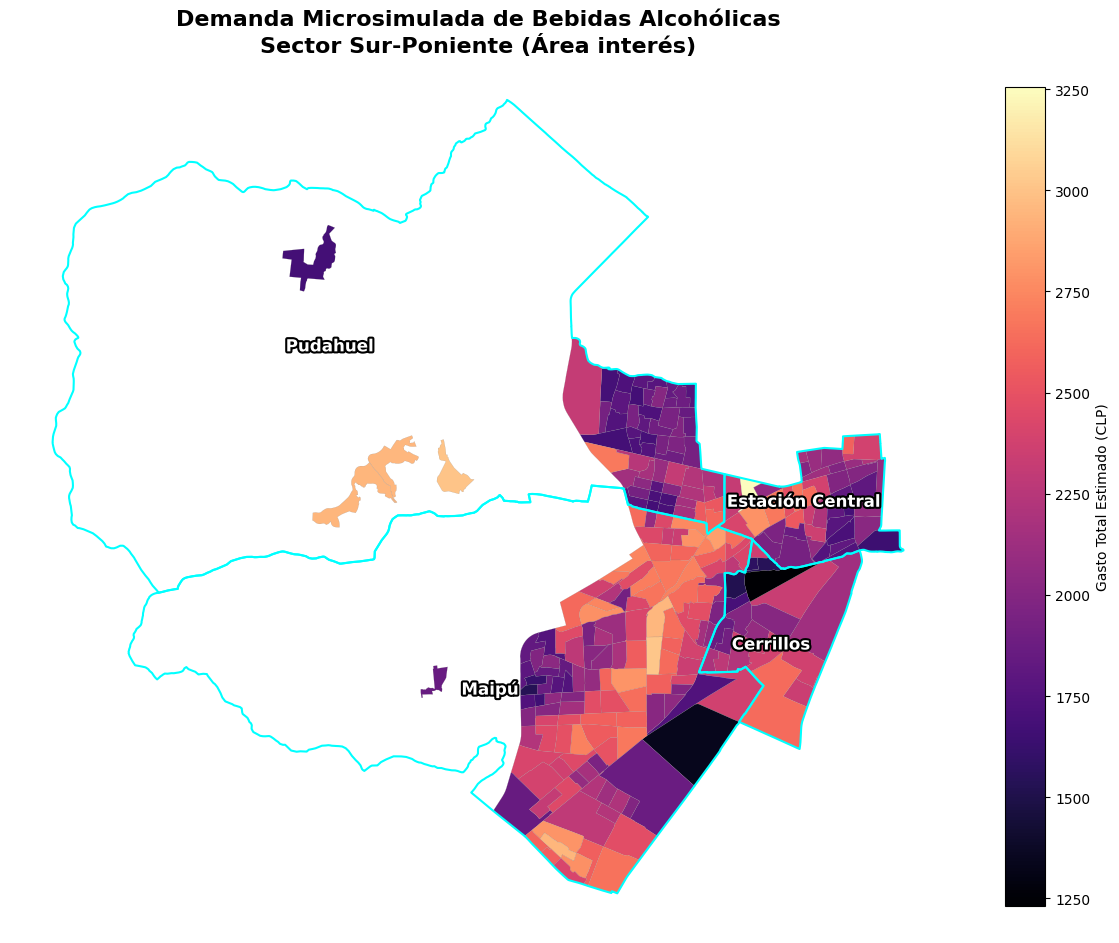

In [250]:
# 1. MAPA DE LA DEMANDA POTENCIAL (7LIRAS)
zonas_mapa = censo_zonal.set_index(ZONA_ID).join(resultados_zona[["demanda_total", "demanda_percap"]])

fig, ax = plt.subplots(figsize=(12, 12))
zonas_mapa.plot(
    column="demanda_percap", cmap="magma", linewidth=0.1, edgecolor="grey",
    legend=True, missing_kwds={"color": "lightgrey"}, ax=ax,
    legend_kwds={'label': "Gasto Total Estimado (CLP)", 'shrink': 0.7}
)
censo_comunal.boundary.plot(ax=ax, color="cyan", linewidth=1.5)

for _, fila in censo_comunal.iterrows():
    punto = fila.geometry.representative_point()
    ax.annotate(
        fila["COMUNA"].title(), xy=(punto.x, punto.y), ha="center", va="center",
        fontsize=12, color="white", fontweight="bold", path_effects=[pe.withStroke(linewidth=3, foreground="black")]
    )

ax.set_title("Demanda Microsimulada de Bebidas Alcohólicas\nSector Sur-Poniente (Área interés)", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### 2.6.2 Análisis Mapa Demanda potencial

El mapa de calor refleja la estimación del **gasto promedio por individuo** (ticket per cápita) al interior de cada manzana censal en las comunas del área de estudio. 

A nivel territorial se observan los siguientes patrones visuales:

* **El Corredor de Maipú:** Esta comuna destaca por concentrar la mayor cantidad de "zonas calientes" (tonos naranjas y amarillos) de todo el mapa. Existe un claro aglutinamiento territorial en su sector central y sur, donde los individuos presentan el mayor nivel de gasto promedio.
* **Comportamiento en Estación Central:** En esta comuna predominan los tonos oscuros (morados y magentas). Esto visualiza que el gasto promedio de cada individuo se ubica sistemáticamente en los rangos más bajos de la escala estimada.
* **Realidad Polarizada en Pudahuel:** Las zonas visibles en esta comuna muestran realidades diametralmente opuestas; un sector exhibe un gasto individual mínimo (morado oscuro), mientras que el bloque adyacente resalta con tonos cálidos (naranja claro), indicando un foco altamente concentrado de gasto promedio elevado.
* **Distribución en Cerrillos:** Presenta una distribución predominantemente de nivel medio-bajo (tonos magentas y morados), con algunas zonas negras que indican una demanda individual mínima, mostrando solo leves repuntes de intensidad hacia su límite poniente (frontera con Maipú).

### 2.7 Caracterización de la oferta actual

C:\Users\renat\AppData\Local\Temp\ipykernel_15772\644799579.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poligono_estudio = censo_comunal.geometry.unary_union
C:\Users\renat\AppData\Local\Temp\ipykernel_15772\644799579.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  botillerias["geometry"] = botillerias.centroid


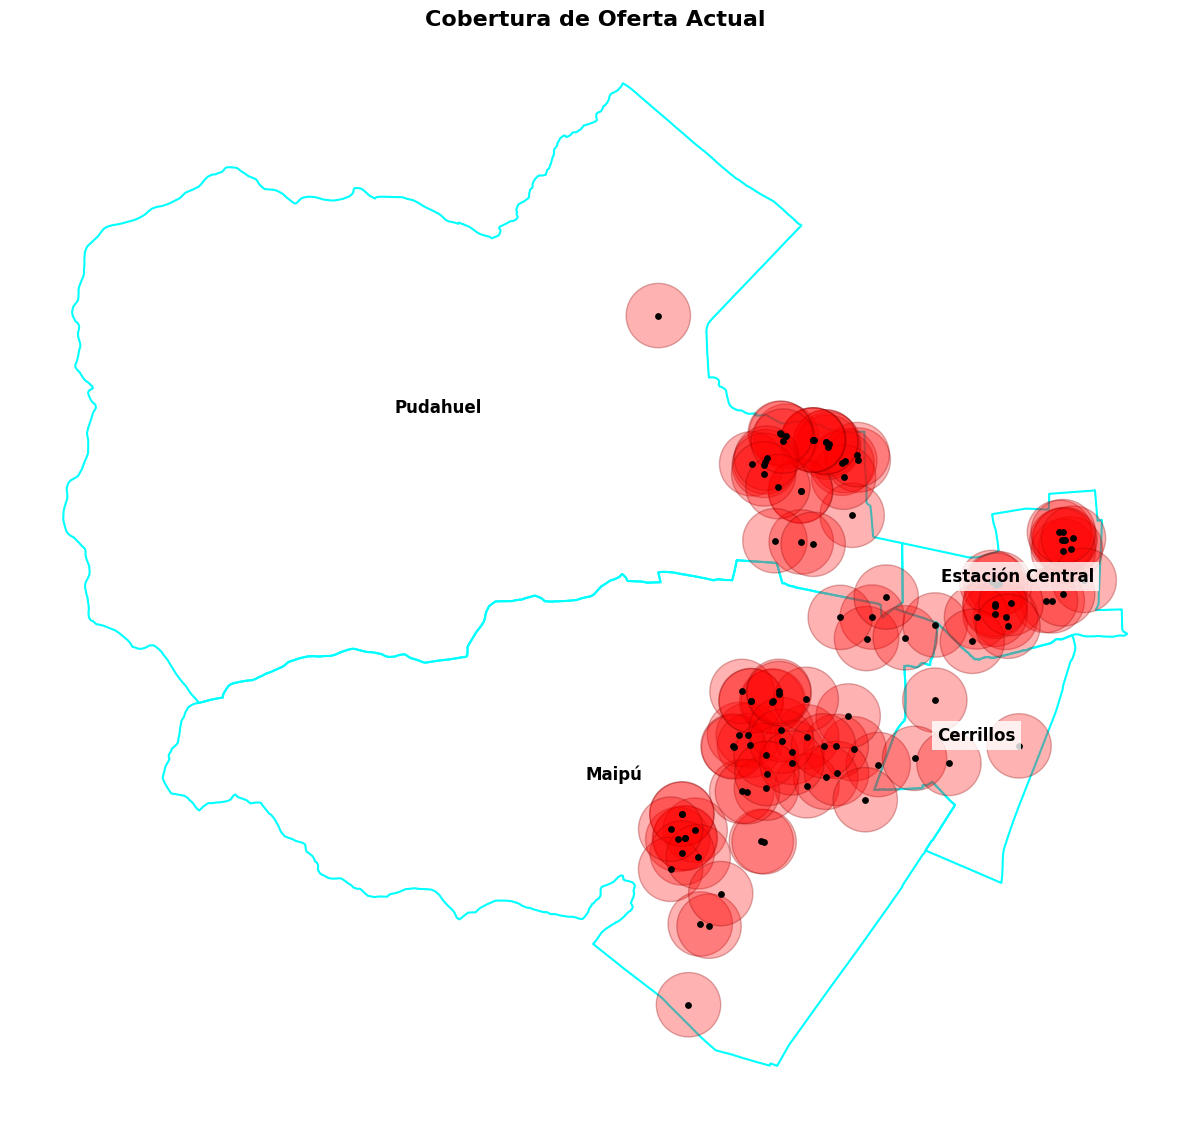

Total de botillerías mapeadas: 110


In [251]:
# 1. UNIMOS LA GEOMETRÍA DE LAS COMUNAS
poligono_estudio = censo_comunal.geometry.unary_union

# 2. DESCARGAMOS LA COMPETENCIA DESDE OPENSTREETMAP
etiquetas = {"shop": "alcohol"}

try:
    botillerias = ox.features_from_polygon(poligono_estudio, etiquetas)
except AttributeError:
    botillerias = ox.geometries_from_polygon(poligono_estudio, etiquetas)

# 3. NOS QUEDAMOS CON LOS CENTROS (ALGUNOS LOCALES VIENEN DIBUJADOS COMO POLÍGONOS)
botillerias["geometry"] = botillerias.centroid

# 4. CREAMOS LOS BUFFERS DE 800 METROS
botillerias_utm = botillerias.to_crs(epsg=32719)
censo_comunal_utm = censo_comunal.to_crs(epsg=32719)

# 5. APLICAMOS EL RADIO DE 800 METROS
botillerias_utm["buffer_800m"] = botillerias_utm.buffer(800)
botillerias_buffers = botillerias_utm.set_geometry("buffer_800m")

# 6. GRAFICAMOS EL MAPA DE LA OFERTA ACTUAL
fig, ax = plt.subplots(figsize=(12, 12))

# DIBUJAMOS LOS BORDES DE LAS COMUNAS EN CYAN
censo_comunal_utm.plot(ax=ax, facecolor="none", edgecolor="cyan", linewidth=1.5)

# DIBUJAMOS LAS ÁREAS DE COBERTURA (BUFFERS) EN ROJO SEMITRANSPARENTE
botillerias_buffers.plot(ax=ax, facecolor="red", alpha=0.3, edgecolor="darkred", linewidth=1)

# DIBUJAMOS EL PUNTO EXACTO DEL LOCAL EN NEGRO
botillerias_utm.set_geometry("geometry").plot(ax=ax, color="black", markersize=15)

# AÑADIMOS LOS NOMBRES DE LAS COMUNAS (OPCIONAL, PARA GUIAR LA VISTA)
for idx, fila in censo_comunal_utm.iterrows():
    ax.annotate(text=fila["COMUNA"].title(), 
                xy=(fila.geometry.centroid.x, fila.geometry.centroid.y),
                horizontalalignment='center', fontsize=12, fontweight='bold', 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.title("Cobertura de Oferta Actual", fontsize=16, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Total de botillerías mapeadas: {len(botillerias)}")

#### 2.7.1 Interpretación Mapa oferta actual

Para analizar la oferta existente y descubrir posibles brechas de mercado, se georreferenciaron los puntos de venta actuales (botillerías y tiendas de licores) en la zona de estudio utilizando los registros de OpenStreetMap. 

**Justificación del Umbral de Cobertura (Buffer de 800m):**
Para estimar el área de influencia real de cada local comercial, se aplicó un buffer de distancia euclidiana de 800 metros. La elección de este umbral responde directamente a la naturaleza del rubro: la venta de licores al por menor funciona bajo una lógica de **comercio de conveniencia y proximidad vecinal**. 
Una distancia de 800 metros equivale aproximadamente a una caminata de 9 a 12 minutos. En la decisión de compra del consumidor de este tipo de bienes, la accesibilidad peatonal y el tiempo de desplazamiento son factores críticos; superado este radio, la probabilidad de que el cliente elija ese local (en lugar de buscar una alternativa más cercana o un supermercado) disminuye drásticamente.

Al visualizar las áreas de cobertura de 800 metros sobre el mapa comunal, se identifican las siguientes dinámicas de mercado:

* **Saturación en Estación Central:** La comuna presenta una altísima densidad de locales comerciales. Los múltiples puntos negros y la fuerte superposición de sus áreas de cobertura (zonas rojas oscuras) indican un mercado altamente competitivo y saturado, dejando nulos espacios desatendidos a nivel barrial.
* **Corredor Comercial en Maipú:** Existe un denso aglutinamiento de competidores a lo largo del sector centro y oriente de la comuna, formando un bloque continuo de cobertura. Sin embargo, el vasto sector poniente de Maipú aparece completamente desprovisto de oferta registrada, marcando un fuerte contraste territorial.
* **Desierto de Oferta en Pudahuel:** A excepción de una zona muy específica ubicada en el límite sur-oriente y un punto aislado, la inmensa mayoría de la superficie de Pudahuel no registra presencia de botillerías bajo el estándar de OpenStreetMap, dejando áreas residenciales potencialmente fuera del alcance peatonal (15 minutos) de cualquier competidor.
* **Oferta Fragmentada en Cerrillos:** La comuna exhibe una distribución de locales más moderada y dispersa, concentrándose principalmente en sus bordes limítrofes con Maipú y Estación Central, lo que genera pequeños vacíos sin cobertura directa en su interior.

## 3. Conclusión

### 3.1 Mapa Diagnóstico territorial: Oferta vs Demanda

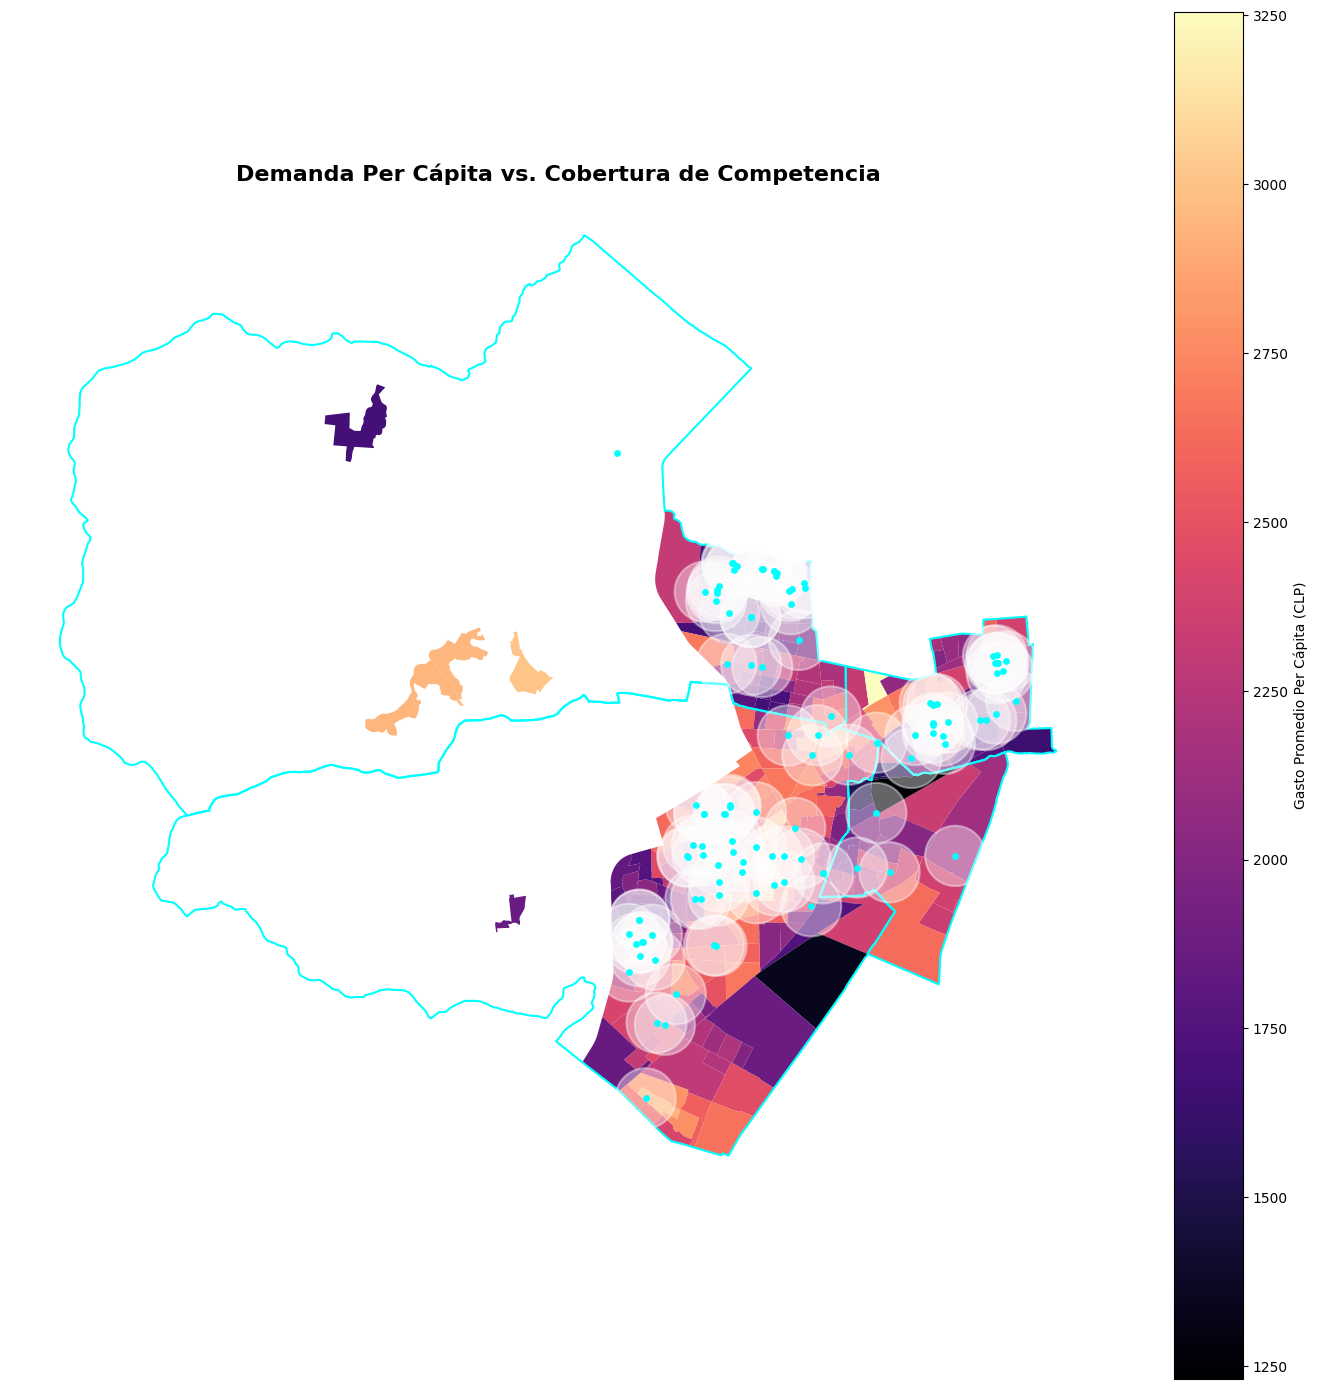

In [252]:
# 1. PREPARAMOS EL MAPA DE CALOR
zonas_mapa_utm = zonas_mapa.to_crs(epsg=32719) 
fig, ax = plt.subplots(figsize=(14, 14))

zonas_mapa_utm.plot(
    column="demanda_percap", 
    cmap="magma", 
    legend=True,
    legend_kwds={"label": "Gasto Promedio Per Cápita (CLP)"},
    ax=ax
)

# BORDES DE LAS COMUNAS
censo_comunal_utm.plot(ax=ax, facecolor="none", edgecolor="cyan", linewidth=1.5)

# 2. LOS BUFFERS DE LA COMPETENCIA (800m)
# USAMOS BLANCO SEMITRANSPARENTE PARA QUE RESALTE SOBRE LOS COLORES OSCUROS DEL MAPA DE CALOR
botillerias_buffers.plot(ax=ax, facecolor="white", alpha=0.4, edgecolor="white", linewidth=1.5)

# 3. LOS PUNTOS DE LA COMPETENCIA (Ubicación exacta)
botillerias_utm.set_geometry("geometry").plot(ax=ax, color="cyan", markersize=15)

# 4. TÍTULO Y FORMATO FINAL
plt.title("Demanda Per Cápita vs. Cobertura de Competencia", fontsize=16, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

#### 3.1.1 Análisis Mapa Diagnóstico territorial: Oferta vs Demanda

El cruce espacial entre la demanda potencial (ticket promedio esperado) y el radio de cobertura de la competencia actual revela oportunidades de mercado altamente asimétricas. Para maximizar la rentabilidad y el alcance de la nueva sucursal de 7LIRAS, se identifican las siguientes directrices estratégicas:

* **Oportunidad Principal (Sur de Maipú):** La zona más atractiva para la expansión se ubica hacia el sector sur de la comuna de Maipú. Este territorio destaca por concentrar bloques censales con alta disposición de gasto per cápita (tonos naranjas oscuros y claros) que logran escapar de la densa saturación comercial del centro de la comuna. Ubicarse estratégicamente en los bordes permitiría capturar de forma exclusiva a clientes de alto ticket que actualmente no cuentan con un local a distancia de caminata.
* **Oportunidad Secundaria (Poniente de Estación Central):** Como segunda alternativa figura el límite poniente de Estación Central. Si bien presenta un atractivo por densidad poblacional, el mapa evidencia que es una zona **altamente saturada** por el comercio de bebidas alcohólicas (fuerte superposición de áreas de cobertura). Ingresar físicamente a este sector implicaría enfrentar una dura competencia vecinal.
* **Zonas a Descartar (Saturación y Bajo Ticket):** Se recomienda descartar de plano el ingreso físico al corredor comercial del centro de Maipú y al sector centro/oriente de Estación Central. En el caso de Maipú, la excesiva concentración de locales (múltiples círculos superpuestos) anula la ventaja del alto gasto per cápita y generaría canibalización. Por su parte, el corazón de Estación Central presenta el peor escenario comercial posible: máxima competencia instalada combinada con el ticket per cápita más bajo de toda el área de estudio (tonos morados oscuros).

### 3.2 Propuesta de localización

A partir del análisis integrado de demanda microsimulada y cobertura espacial de la competencia, se define formalmente que la localización óptima para la apertura de la nueva sucursal física de **Botillería 7LIRAS** corresponde al **sector sur de la comuna de Maipú**.

Esta decisión se fundamenta en los siguientes pilares cuantitativos y estratégicos:

* **Captura de Alto Poder Adquisitivo:** El sector sur de Maipú concentra manzanas censales en los rangos superiores de gasto per cápita estimado (anaranjados), garantizando un ticket promedio por transacción significativamente más alto que el promedio del área de estudio.
* **Vacío de Cobertura Peatonal:** Al emplazarse en los bordes inmediatos de la mancha comercial consolidada, la sucursal operará fuera del umbral de accesibilidad de 800 metros (10–15 minutos a pie) de los competidores actuales, asegurando un área de influencia cautiva y mitigando el riesgo de canibalización.

#### 3.2.1 Mapa Ubicación nueva botillería

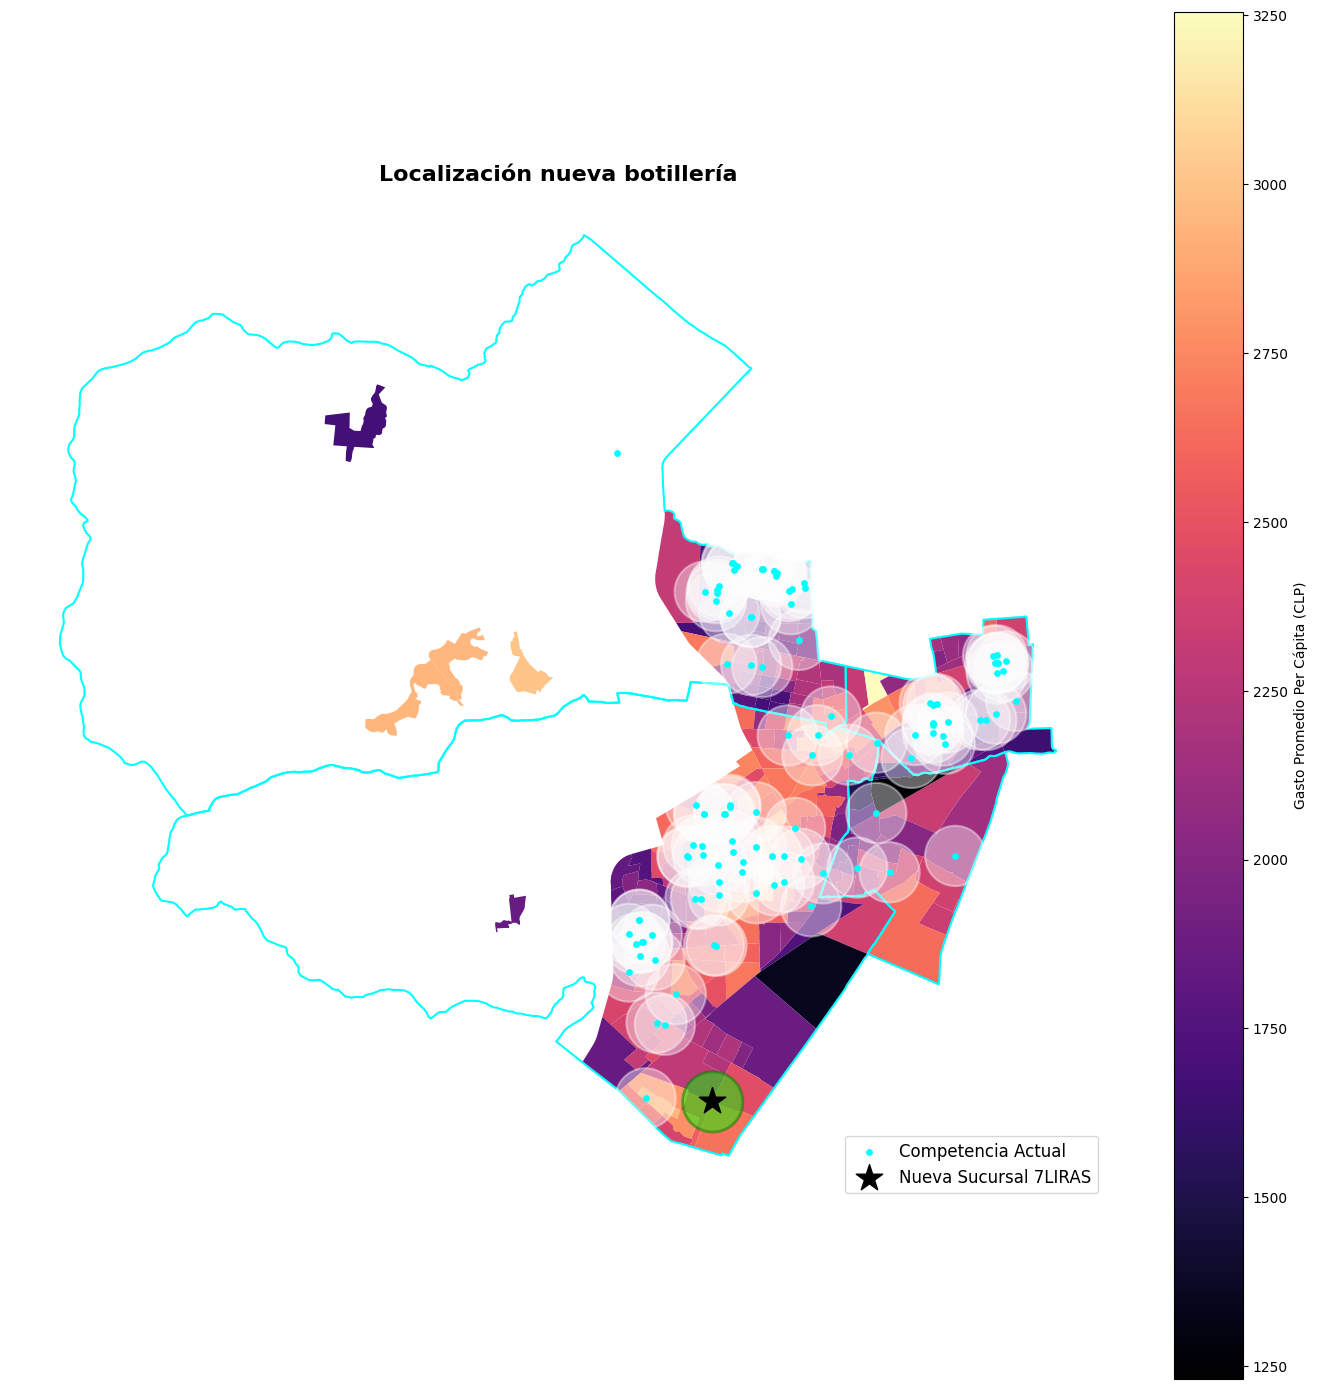

In [253]:
# 1. PREPARAMOS EL MAPA DE CALOR
zonas_mapa_utm = zonas_mapa.to_crs(epsg=32719) 
fig, ax = plt.subplots(figsize=(14, 14))

zonas_mapa_utm.plot(
    column="demanda_percap", 
    cmap="magma", 
    legend=True,
    legend_kwds={"label": "Gasto Promedio Per Cápita (CLP)"},
    ax=ax
)

# 2. CAPAS BASE Y COMPETENCIA
censo_comunal_utm.plot(ax=ax, facecolor="none", edgecolor="cyan", linewidth=1.5)
botillerias_buffers.plot(ax=ax, facecolor="white", alpha=0.4, edgecolor="white", linewidth=1.5)
botillerias_utm.set_geometry("geometry").plot(ax=ax, color="cyan", markersize=15, label="Competencia Actual")

# 3. UBICACIÓN NUEVA BOTI
lon_final = -70.7715
lat_final = -33.5585

# EL PUNTO DE LA NUEVA BOTI NO SE MOVÍA ASÍ QUE GEMINI ME SUGIRIÓ ESTO
punto_gps = gpd.GeoDataFrame(geometry=[Point(lon_final, lat_final)], crs="EPSG:4326")
punto_utm = punto_gps.to_crs(epsg=32719)

# CREAMOS EL BUFFER AL NUEVO PUNTO
punto_utm["radio_800m"] = punto_utm.buffer(800)
punto_buffer = punto_utm.set_geometry("radio_800m")

# 4. GRAFICAMOS EL PUNTO COMO ESTRELLA ESTRELLA
punto_buffer.plot(ax=ax, facecolor="lime", alpha=0.5, edgecolor="green", linewidth=2)
punto_utm.set_geometry("geometry").plot(ax=ax, color="black", marker="*", markersize=400, label="Nueva Sucursal 7LIRAS")

# 5. TÍTULO Y FORMATO FINAL
plt.title("Localización nueva botillería", fontsize=16, fontweight="bold")
plt.legend(loc="lower right", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

### 3.3 Perfil sociodemográfico de la población beneficiada

In [254]:
# 1. CREAR EL GEODATAFRAME DEL BUFFER 
buffer_gdf = gpd.GeoDataFrame(geometry=punto_buffer.geometry, crs="EPSG:32719")

# CONVERTIMOS EL CENSO (EPSG:4674) A METROS (EPSG:32719) PARA QUE CALCEN
censo_zonal_utm = censo_zonal.to_crs(epsg=32719)

# 2. INTERSECCIÓN ESPACIAL
censo_buffer = gpd.sjoin(censo_zonal_utm, buffer_gdf, how="inner", predicate="intersects")

# 3. CÁLCULO DE TOTALES
col_total = 'n_per' 
col_profesionales = 'n_cine_terciaria_maestria_doctorado'
col_hombres = 'n_hombres'
col_mujeres = 'n_mujeres'

# TOTALES POBLACIONALES EN LA ZONA
pob_total_zona = censo_buffer[col_total].sum()
total_profesionales = censo_buffer[col_profesionales].sum()
total_hombres = censo_buffer[col_hombres].sum()
total_mujeres = censo_buffer[col_mujeres].sum()

# EDADES
tot_menores = censo_buffer[['n_edad_0_5', 'n_edad_6_13', 'n_edad_14_17']].sum().sum()
tot_jovenes = censo_buffer['n_edad_18_24'].sum()
tot_adultos = censo_buffer[['n_edad_25_44', 'n_edad_45_59']].sum().sum()
tot_mayores = censo_buffer['n_edad_60_mas'].sum()

# 4. CÁLCULO DE PORCENTAJES
pct_profesionales = (total_profesionales / pob_total_zona) * 100
pct_hombres = (total_hombres / pob_total_zona) * 100
pct_mujeres = (total_mujeres / pob_total_zona) * 100

pct_menores = (tot_menores / pob_total_zona) * 100
pct_jovenes = (tot_jovenes / pob_total_zona) * 100
pct_adultos = (tot_adultos / pob_total_zona) * 100
pct_mayores = (tot_mayores / pob_total_zona) * 100

# 5. ESTADÍSTICAS DESCRIPTIVAS DEL GASTO PER CÁPITA
buffer_gdf = gpd.GeoDataFrame(geometry=punto_buffer.geometry, crs="EPSG:32719")

# 6. INTERSECCIÓN CON EL MAPA DE DEMANDA
zonas_demanda_buffer = gpd.sjoin(zonas_mapa_utm, buffer_gdf, how="inner", predicate="intersects")

# 7. ESTADÍSTICAS
gasto_promedio = zonas_demanda_buffer['demanda_percap'].mean()
gasto_minimo = zonas_demanda_buffer['demanda_percap'].min()
gasto_maximo = zonas_demanda_buffer['demanda_percap'].max()
gasto_mediana = zonas_demanda_buffer['demanda_percap'].median()


# 8. RESULTADOS
print(f"Perfil sociodemográfico: Nueva sucursal 7LIRAS (Maipú Sur)")
print(f"Población Total en el radio: {pob_total_zona:,.0f} habitantes\n")

print(f"1. PERFIL EDUCATIVO")
print(f"- Profesionales / Educ. Superior: {pct_profesionales:.1f}%\n")

print(f"2. DISTRIBUCIÓN POR SEXO")
print(f"- Hombres: {pct_hombres:.1f}%")
print(f"- Mujeres: {pct_mujeres:.1f}%\n")

print(f"3. DISTRIBUCIÓN ETARIA")
print(f"- Menores de edad: {pct_menores:.1f}%")
print(f"- Jóvenes adultos: {pct_jovenes:.1f}%")
print(f"- Adultos: {pct_adultos:.1f}%")
print(f"- Adultos mayores: {pct_mayores:.1f}%")

print(f"Total de zonas censales capturadas en el radio: {len(zonas_demanda_buffer)}\n")
print(f"Gasto Promedio Per Cápita: ${gasto_promedio:,.0f} CLP")
print(f"Mediana del Gasto: ${gasto_mediana:,.0f} CLP")
print(f"Rango de Gasto: Desde ${gasto_minimo:,.0f} hasta ${gasto_maximo:,.0f} CLP\n")

Perfil sociodemográfico: Nueva sucursal 7LIRAS (Maipú Sur)
Población Total en el radio: 24,992 habitantes

1. PERFIL EDUCATIVO
- Profesionales / Educ. Superior: 35.6%

2. DISTRIBUCIÓN POR SEXO
- Hombres: 48.4%
- Mujeres: 51.6%

3. DISTRIBUCIÓN ETARIA
- Menores de edad: 25.6%
- Jóvenes adultos: 10.7%
- Adultos: 51.4%
- Adultos mayores: 12.3%
Total de zonas censales capturadas en el radio: 7

Gasto Promedio Per Cápita: $2,544 CLP
Mediana del Gasto: $2,574 CLP
Rango de Gasto: Desde $2,235 hasta $2,804 CLP



#### 3.3.1 Análisis sociodemográfico de la población beneficiada

El cruce de datos espaciales en el radio de influencia (800 metros, abarcando 7 zonas censales) confirma la viabilidad comercial y el alto potencial de la nueva ubicación para la expansión territorial. 

**1. Público objetivo y género**
* **Masa Crítica:** El polígono captura una población total de **24.992 habitantes**, lo que garantiza un volumen de demanda estructuralmente sólido para la operación.
* **Público Objetivo:** El **62.1%** de los residentes son Jóvenes Adultos (10.7%) y Adultos (51.4%). Esta alta concentración de población económicamente activa y en edad legal de consumo asegura una base de clientes madura y constante.
* **Equilibrio de Género:** La distribución es homogénea (51.6% mujeres y 48.4% hombres), lo cual es óptimo considerando que el modelo econométrico previo descartó el sexo como una variable que sesgue el volumen de compra.

**2. Perfil Socioeconómico y Comportamiento de Gasto**
* **Impulsores de Gasto:** Un **35.6%** de los vecinos cuenta con educación superior o técnica. Al ser esta una variable predictora clave del nivel de compra (según el análisis OLS), asegura la propensión a un ticket promedio más alto.
* **Capacidad Adquisitiva:** El análisis económico arroja un Gasto Promedio Per Cápita de **\$2.544 CLP** (con un rango entre \$2.235 y \$2.804 CLP). La mediana se sitúa en **\$2.574 CLP**, lo que indica que más de la mitad de la población de la zona gasta por sobre el promedio general, reflejando un poder adquisitivo consistente y estable.

**Conclusión:**
El análisis de estos datos duros valida la decisión estratégica: la sucursal penetrará en un vecindario de casi 25.000 personas que no solo carecen de oferta competitiva cercana, sino que poseen el perfil etario y socioeconómico exacto para maximizar la rentabilidad anual del proyecto.